In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

C:\Users\admin\AppData\Local\Temp\ipykernel_33796\3744190102.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='pick_frequency', y='stock_code', data=top_fast_skus, palette='Blues_r')


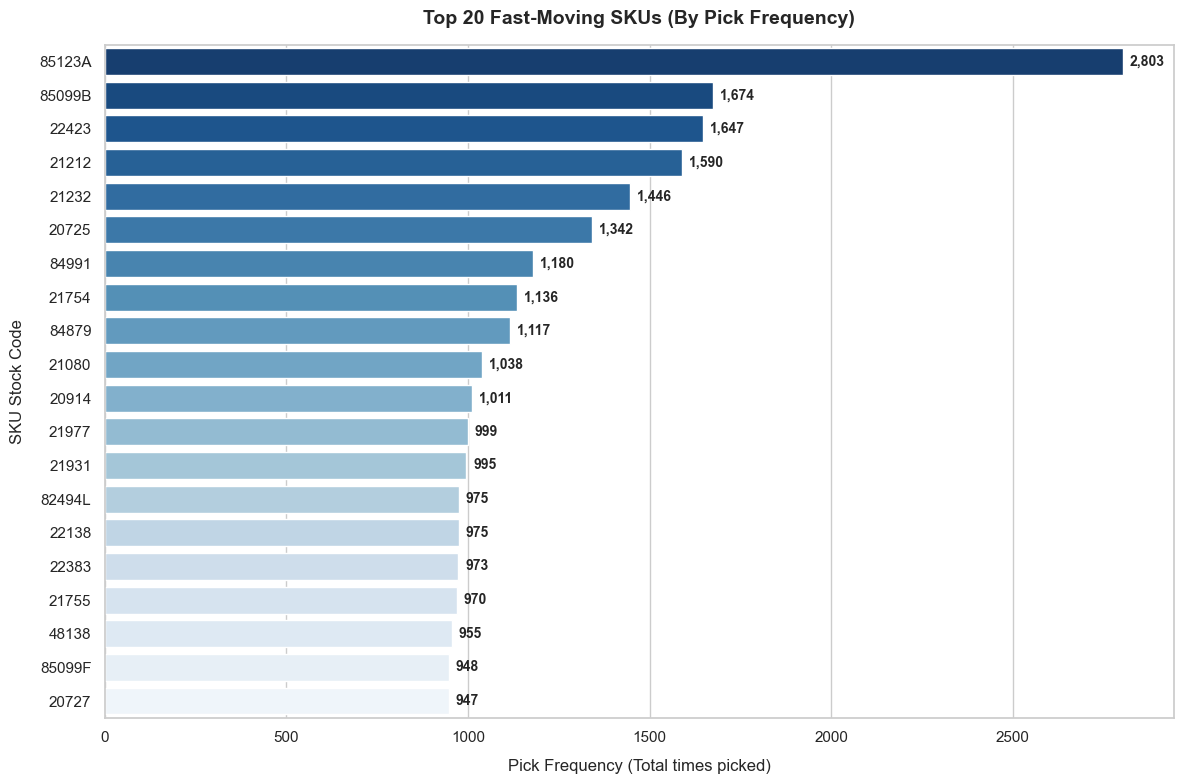

In [2]:
# =====================================================================
# TOP 20 FAST-MOVING SKUs (BASED ON PICK FREQUENCY)
# =====================================================================

# 1. Load feature data (This file is already aggregated, 1 row per SKU)
# Path adjusted to fit the standard project structure
df = pd.read_csv('../features/sku_features.csv')

# 2. Sort data descending by 'pick_frequency' and extract the top 20
top_fast_skus = df.sort_values(by='pick_frequency', ascending=False).head(20)

# 3. Configure plot style and size
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 4. Plot horizontal bar chart and save the axes object ('ax') for annotation
ax = sns.barplot(x='pick_frequency', y='stock_code', data=top_fast_skus, palette='Blues_r')

# 5. Set chart title and axis labels
plt.title('Top 20 Fast-Moving SKUs (By Pick Frequency)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pick Frequency (Total times picked)', fontsize=12, labelpad=10)
plt.ylabel('SKU Stock Code', fontsize=12, labelpad=10)

# 6. ADD DATA LABELS (Highly recommended for final reporting)
for p in ax.patches:
    width = p.get_width()
    # Add the text label right next to each bar
    ax.annotate(f'{int(width):,}', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

# 7. Adjust layout and display plot
plt.tight_layout()
plt.show()

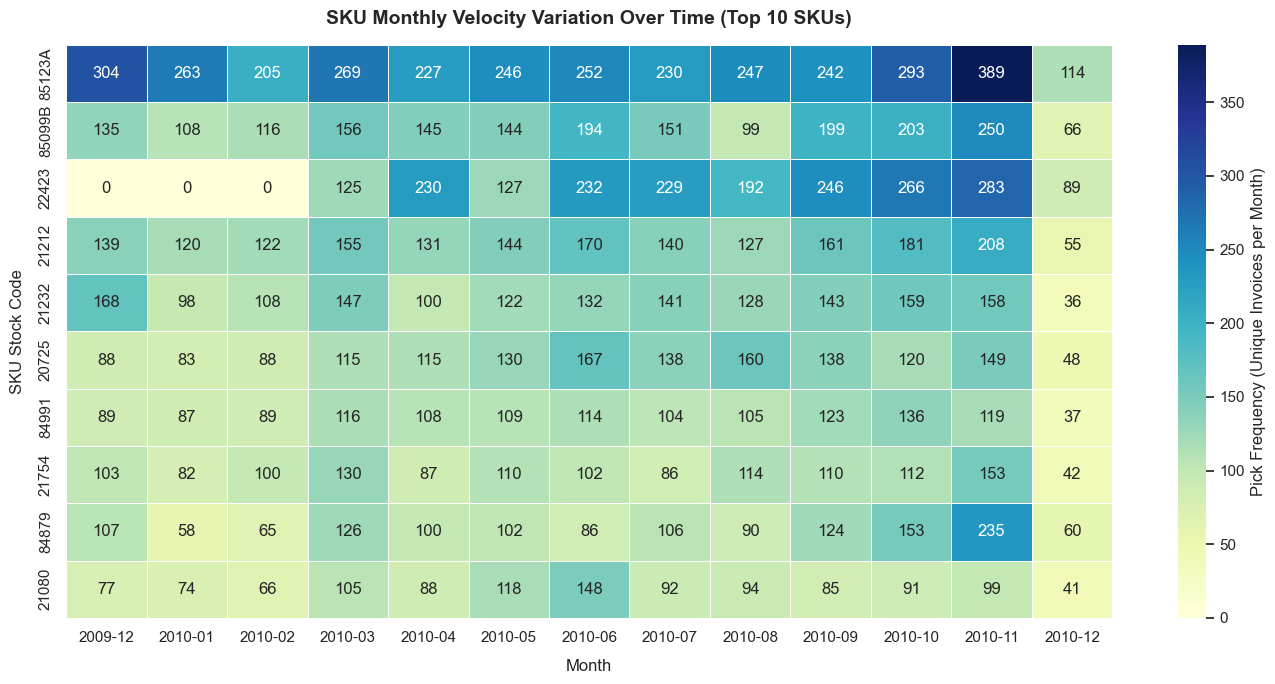

In [3]:
# =====================================================================
# HEATMAP: MONTHLY VELOCITY VARIATION OF TOP 10 SKUS
# =====================================================================

# 1. Read data from the processed files
df_clean = pd.read_csv('../data/processed/data_clean.csv') 
df_features = pd.read_csv('../features/sku_features.csv')

# 2. Extract the Top 10 fast-moving SKUs based on pick frequency
# Since sku_features.csv is already aggregated, we sort and pick the top 10 directly
top_10_skus = df_features.sort_values(by='pick_frequency', ascending=False).head(10)['stock_code'].tolist()

# 3. Filter the transaction history to keep only the selected Top 10 SKUs
df_top_clean = df_clean[df_clean['stock_code'].isin(top_10_skus)].copy()

# 4. Create a Year-Month (YYYY-MM) feature for time series tracking
# Convert order_date to datetime format to safely extract the period
df_top_clean['order_date'] = pd.to_datetime(df_top_clean['order_date'])
df_top_clean['year_month'] = df_top_clean['order_date'].dt.strftime('%Y-%m')

# 5. Build the heatmap matrix using pivot_table
# We use 'nunique' on 'invoice_no' to correctly calculate Pick Frequency (Velocity)
heatmap_data = df_top_clean.pivot_table(
    index='stock_code', 
    columns='year_month', 
    values='invoice_no', 
    aggfunc='nunique' 
)

# Fill missing transaction periods with 0
heatmap_data = heatmap_data.fillna(0)

# Reindex the Y-axis to strictly follow the Top 10 sorting order (Highest to lowest)
heatmap_data = heatmap_data.reindex(top_10_skus)

# 6. Configure plot style and dimensions
plt.figure(figsize=(14, 7))
sns.set_theme(style="white")

# 7. Plot the heatmap with Seaborn
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.5, 
            cbar_kws={'label': 'Pick Frequency (Unique Invoices per Month)'})

# 8. Set chart title and axis labels
plt.title('SKU Monthly Velocity Variation Over Time (Top 10 SKUs)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12, labelpad=10)
plt.ylabel('SKU Stock Code', fontsize=12, labelpad=10)

# 9. Adjust layout and display the visualization
plt.tight_layout()
plt.show()

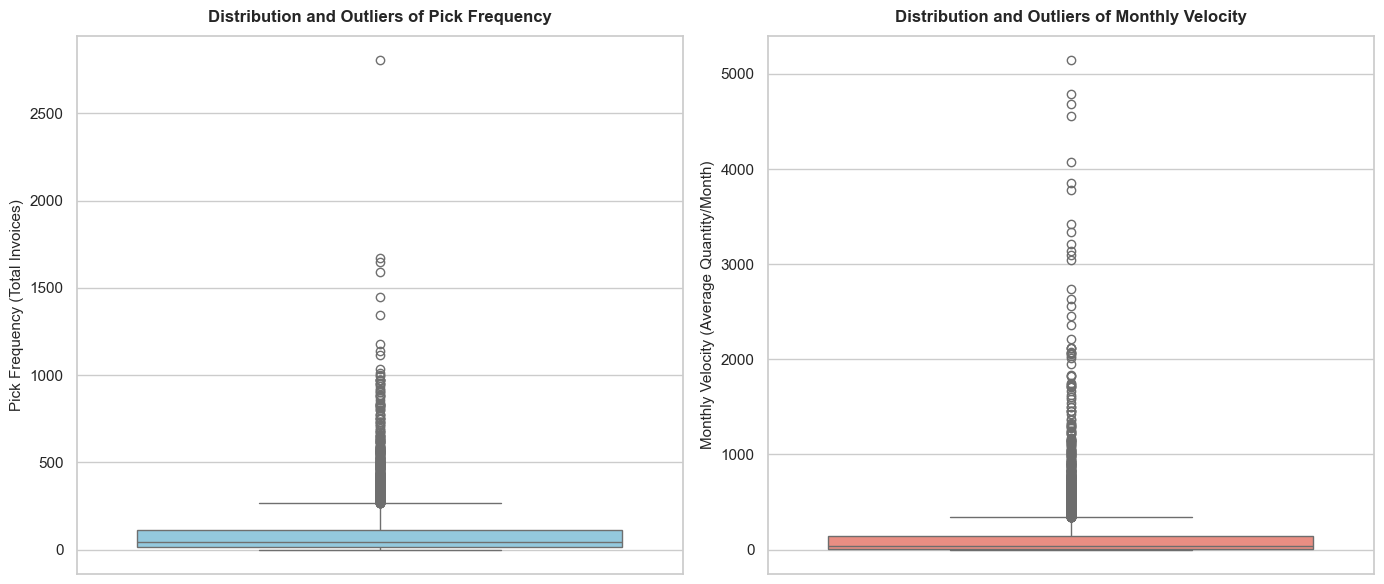

In [4]:
# =====================================================================
# BOX PLOTS: OUTLIER DETECTION FOR SLOTTING FEATURES
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load SKU feature data
df_sku = pd.read_csv('../features/sku_features.csv')

# 2. Configure plot style and subplots setup
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 3. Plot 1: Distribution of Pick Frequency
sns.boxplot(data=df_sku, y='pick_frequency', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution and Outliers of Pick Frequency', fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('Pick Frequency (Total Invoices)', fontsize=11)

# 4. Plot 2: Distribution of Monthly Velocity
sns.boxplot(data=df_sku, y='monthly_velocity', ax=axes[1], color='salmon')
axes[1].set_title('Distribution and Outliers of Monthly Velocity', fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('Monthly Velocity (Average Quantity/Month)', fontsize=11)

# 5. Adjust layout and display the visualization
plt.tight_layout()
plt.show()

In [ ]:
#Quantifying Distribution & Outliers (IQR Method)
def calculate_data_distribution(df, column_name):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    # Calculate IQR (Interquartile Range)
    IQR = Q3 - Q1
    # Calculate lower and upper bounds (1.5 * IQR rule for Boxplots)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Count Outliers
    outliers_count = len(df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)])
    # Count Inliers
    inliers_count = len(df) - outliers_count
    total_count = len(df)
    outlier_percentage = (outliers_count / total_count) * 100
    inlier_percentage = (inliers_count / total_count) * 100
    print(f"--- DISTRIBUTION STATISTICS FOR COLUMN '{column_name.upper()}' ---")
    print(f"Normal Range (Mathematical): From {lower_bound:.2f} to {upper_bound:.2f}")
    print(f"✅ Inliers count : {inliers_count:,.0f} rows | Percentage: {inlier_percentage:.2f}%")
    print(f"🚨 Outliers count: {outliers_count:,.0f} rows | Percentage: {outlier_percentage:.2f}%\n")
# Run distribution check for your monthly SKU data
calculate_data_distribution(df_sku, 'monthly_velocity')
calculate_data_distribution(df_sku, 'pick_frequency') 

--- DISTRIBUTION STATISTICS FOR COLUMN 'MONTHLY_VELOCITY' ---
Normal Range (Mathematical): From -190.27 to 338.45
✅ Inliers count : 3,580 rows | Percentage: 88.94%
🚨 Outliers count: 445 rows | Percentage: 11.06%

--- DISTRIBUTION STATISTICS FOR COLUMN 'PICK_FREQUENCY' ---
Normal Range (Mathematical): From -140.00 to 268.00
✅ Inliers count : 3,639 rows | Percentage: 90.41%
🚨 Outliers count: 386 rows | Percentage: 9.59%



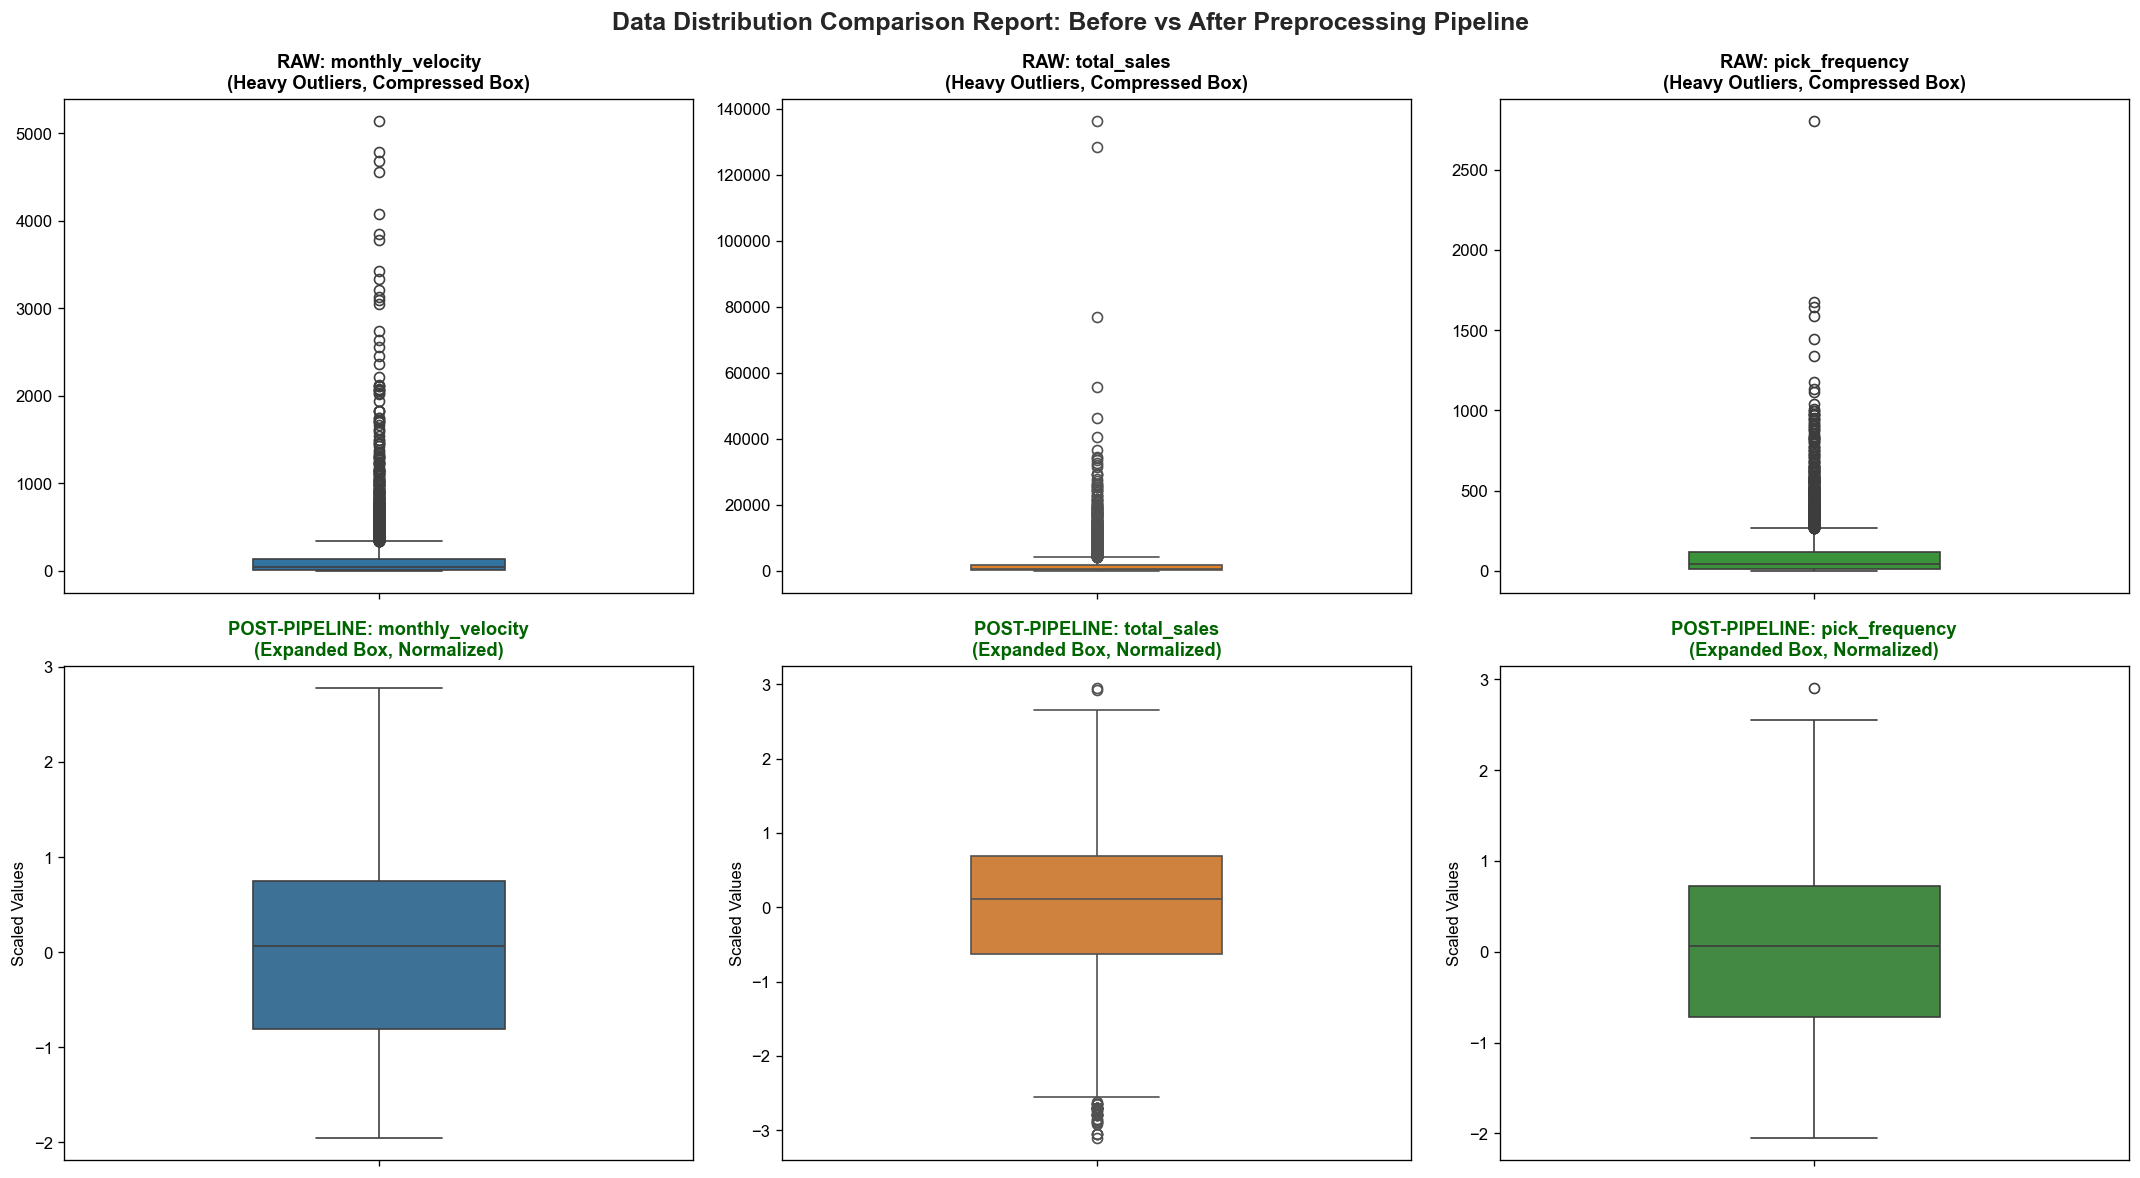

In [1]:
# =====================================================================
# DATA DISTRIBUTION COMPARISON: BEFORE VS AFTER PIPELINE (UPDATED)
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Pipeline function to generate scaled data for plotting (Matches the real model)
def optimize_preprocessing_pipeline(data, feature_cols):
    df_out = data[feature_cols].copy()
    for col in feature_cols:
        # Only use Log1p exactly as when training K-Means
        df_out[col] = np.log1p(df_out[col])
        
    # Use StandardScaler instead of RobustScaler
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_out)
    df_scaled = pd.DataFrame(scaled_data, columns=feature_cols, index=data.index)
    return df_scaled

# 2. Load raw data and extract features
df_raw = pd.read_csv('../features/sku_features.csv')
features = ['monthly_velocity', 'total_sales', 'pick_frequency']

# 3. Generate scaled data dynamically
df_scaled = optimize_preprocessing_pipeline(df_raw, features)

# 4. Initialize smart plot grid: 2 rows x 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=120)
sns.set_theme(style="whitegrid")

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, col in enumerate(features):
    # --- ROW 1: ORIGINAL RAW STATE ---
    sns.boxplot(data=df_raw, y=col, ax=axes[0, i], color=colors[i], width=0.4)
    axes[0, i].set_title(f'RAW: {col}\n(Heavy Outliers, Compressed Box)', fontsize=11, fontweight='bold')
    axes[0, i].set_ylabel('')
    
    # --- ROW 2: POST-PIPELINE STATE ---
    sns.boxplot(data=df_scaled, y=col, ax=axes[1, i], color=colors[i], width=0.4, saturation=0.6)
    axes[1, i].set_title(f'POST-PIPELINE: {col}\n(Expanded Box, Normalized)', fontsize=11, fontweight='bold', color='darkgreen')
    axes[1, i].set_ylabel('Scaled Values')

# 5. Add global title and display
plt.suptitle('Data Distribution Comparison Report: Before vs After Preprocessing Pipeline', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()